In [100]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [101]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from plot_params import *
import scipy.stats as stats
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# Run scan_L_A.py to generate the results for Fig2.ipynb


In [102]:
def schatten_2_over_L(A, L):
    p = 2.0 / L
    
    # Compute singular values
    s = np.linalg.svd(A, compute_uv=False)
    
    # Compute Schatten-p norm
    return np.sum(s**p)**(1.0/p)

In [103]:

df_sweep_s_a = pd.read_csv('./sweep_S_A_seed_circular_df.csv')  
df_sweep_s_a

,L,A,NC1,PR,order,S
0,NaN,23,-0.958782,3.003978,0.552847,65.0
1,NaN,21,-0.461793,7.370656,0.371481,55.0
2,NaN,10,-0.480648,4.554436,0.034190,40.0
3,NaN,11,-0.897435,2.603503,0.081924,65.0
4,NaN,35,-0.500077,18.693643,0.017927,80.0
...,...,...,...,...,...,...
4395,NaN,1,-0.353512,16.554903,0.097670,85.0
4396,NaN,6,-0.521013,4.432492,0.246097,45.0
4397,NaN,13,-0.710262,3.493456,0.557149,50.0
4398,NaN,25,-1.264402,2.380862,0.000000,80.0


In [104]:

import pickle as pkl

df_sweep_s_a = pd.read_csv('sweep_S_A_seed_circular_df.csv')  


metrics = ['order', 'PR']
S_values = df_sweep_s_a['S'].sort_values().unique() # np.arange(20, 50)
S_values = S_values[20 <= S_values]
A_col = 'A'
S_col = 'S'
metric = 'PR'
thresh_arr = np.zeros((len(S_values), 100))
means_l = []
A_sorted_l = []
for i, S_val in tqdm(enumerate(S_values)):
    # Select rows with S == S_val
    df_S = df_sweep_s_a[df_sweep_s_a[S_col] == S_val]
    # Drop NaN in A or metric
    df_S = df_S[[A_col, metric]].dropna()
    # Sort A for consistent x-axis
    A_sorted = sorted(df_S[A_col].unique())
    for j in range(100):
        vals = []
        for a in A_sorted:
            val = np.random.choice(df_S[df_S[A_col] == a][metric].values)
            vals.append(val)
        vals = np.array(vals)
        thresh = (max(vals)-min(vals))*0.1+min(vals)
        A_thresh = np.where(vals<thresh)[0][0] / S_val
        thresh_arr[i, j] = A_thresh
    means = []
    stds = []
    for a in A_sorted:
        vals = df_S[df_S[A_col] == a][metric].values
        means.append(np.median(vals) if len(vals) > 0 else np.nan)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    cmap = plt.get_cmap('plasma')
    norm = mcolors.Normalize(vmin=S_values.min(), vmax=S_values.max()+5)
    color = cmap(norm(S_val))
    A_sorted_l.append(A_sorted)
    means_l.append(means)

16it [00:08,  1.90it/s]


In [105]:
def panel_label(ax, label):
    ax.text(
        -0.2, 1.2, label,
        transform=ax.transAxes,      # use axes coordinates
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='left'
    )

16it [00:00, 2839.51it/s]
/tmp/ipykernel_1999112/4271230805.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


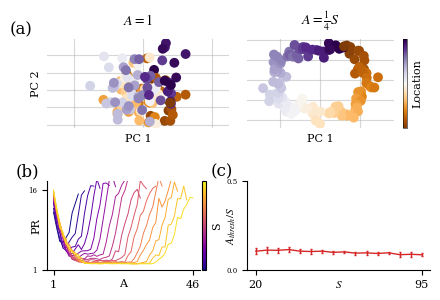

In [106]:
# Use the global matplotlib styling set above
fig = plt.figure(figsize=(FIG_WIDTH*0.9, 3))
gs = GridSpec(2, 2, height_ratios=[1, 1], hspace=0.6, wspace=0.1)

# --- First row: 2D PCA plots for two datasets ---

# Load the two specific files
file1 = '../results/sweep_S_A_seed_circular/data_max_move_1_length_corridors_[np.int64(40)]_seed_1.pkl'
file2 = '../results/sweep_S_A_seed_circular/data_max_move_9_length_corridors_[np.int64(40)]_seed_1.pkl'

with open(file1, 'rb') as f:
    data_dict1 = pkl.load(f)

with open(file2, 'rb') as f:
    data_dict2 = pkl.load(f)

ax_pca1 = fig.add_subplot(gs[0, 0])
plot_pca_subplot(ax_pca1, data_dict1, r'$A=1$')

ax_pca2 = fig.add_subplot(gs[0, 1])
plot_pca_subplot(ax_pca2, data_dict2, r'$A=\frac{1}{4}S$', cb=True, y_label=False)


# --- Second row: original 3 heatmaps ---

axs = [fig.add_subplot(gs[1, i]) for i in range(2)]

### 2 left plots
for i, S_val in tqdm(enumerate(S_values)):
    color = cmap(norm(S_val))
    axs[0].plot(A_sorted_l[i], means_l[i], color=color, label=f"S={S_val}", lw=0.7)
axs[0].set_xlabel("A")
axs[0].set_ylabel(metric, labelpad=-10)
axs[0].set_xticks([1, A_sorted_l[-1][-1]])
axs[0].set_ylim([1, max(means_l[-1])*1.1])
axs[0].set_yticks([1, int(max(means_l[-1]))])
axs[0].xaxis.set_label_coords(0.5, -0.1)

# Add colorbar after the loop
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=min(S_values), vmax=max(S_values))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs[0], pad=0.01)
cbar.set_label('S')
cbar.ax.set_yticklabels([])  # Remove colorbar ticks
cbar.ax.set_yticks([])
# Convert thresh_l_l to array for easier manipulation

means = np.mean(thresh_arr, axis=1)
sems = np.std(thresh_arr, axis=1)
axs[1].errorbar(S_values, means, yerr=sems, lw=1, c='tab:red', fmt='-o', capsize=0.5, markersize=0)
axs[1].set_xlabel(r'$S$')
axs[1].set_ylabel(r'$A_{thresh}/S$', labelpad=-8)
axs[1].set_ylim(0, 0.5)
axs[1].set_xticks([S_values[0], S_values[-1]])
axs[1].set_yticks([0, 0.5])
axs[1].xaxis.set_label_coords(0.5, -0.1)

panel_label(ax_pca1, '(a)')
panel_label(axs[0], '(b)')
panel_label(axs[1], '(c)')
plt.tight_layout()
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig_circ.png', dpi=300, bbox_inches='tight')
plt.show()
